<a href="https://colab.research.google.com/github/jnrahul92/FastAI_Learn/blob/main/Chapter_9_Fast_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#hide
! [ -e /content ] && pip install -Uqq fastbook kaggle waterfallcharts treeinterpreter dtreeviz==1.4.1
import fastbook
fastbook.setup_book()

In [2]:
#hide
from fastbook import *
from pandas.api.types import is_string_dtype, is_numeric_dtype, is_categorical_dtype
from fastai.tabular.all import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from dtreeviz.trees import *
from IPython.display import Image, display_svg, SVG

pd.options.display.max_rows = 20
pd.options.display.max_columns = 8

In [148]:
creds = '{"username":"","key":""}'

In [4]:
cred_path = Path('~/.kaggle/kaggle.json').expanduser()
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text(creds)
    cred_path.chmod(0o600)

In [5]:
comp = 'bluebook-for-bulldozers'
path = URLs.path(comp)
path

Path('/root/.fastai/archive/bluebook-for-bulldozers')

In [6]:
#hide
Path.BASE_PATH = path

In [7]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('bluebook-for-bulldozers')

print("Path to competition files:", path)

KaggleApiHTTPError: 401 Client Error.

You don't have permission to access resource at URL: https://api.kaggle.com/competitions/bluebook-for-bulldozers
Please make sure you are authenticated and have accepted the competition rules which can be found at this location: https://api.kaggle.com/competitions/bluebook-for-bulldozers/rules

In [9]:
import zipfile

zip_path = "/content/bluebook-for-bulldozers.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted!")

Files extracted!


In [10]:
df = pd.read_csv("/content/data/TrainAndValid.csv", low_memory=False)

In [11]:
df['ProductSize'].unique()

array([nan, 'Medium', 'Small', 'Large / Medium', 'Mini', 'Large', 'Compact'], dtype=object)

In [12]:
sizes = 'Large','Large / Medium','Medium','Small','Mini','Compact'

In [13]:
df['ProductSize'] = df['ProductSize'].astype('category')

In [18]:
df['ProductSize'] = df['ProductSize'].cat.set_categories(sizes, ordered=True)

In [19]:
dep_var = 'SalePrice'
df[dep_var] = np.log(df[dep_var])

In [20]:
df = add_datepart(df, 'saledate')

In [21]:
df_test = pd.read_csv("/content/data/Test.csv", low_memory=False)
df_test = add_datepart(df_test, 'saledate')

In [22]:
' '.join(o for o in df.columns if o.startswith('sale'))

'saleYear saleMonth saleWeek saleDay saleDayofweek saleDayofyear saleIs_month_end saleIs_month_start saleIs_quarter_end saleIs_quarter_start saleIs_year_end saleIs_year_start saleElapsed'

In [29]:
cond = (df.saleYear<2011) | (df.saleMonth<10)
train_idx = np.where(cond)[0]
valid_idx = np.where(~cond)[0]

In [30]:
splits = (list(train_idx),list(valid_idx))

In [31]:
cont, cat = cont_cat_split(df, 1, dep_var=dep_var)

In [32]:
to = TabularPandas(df, procs=[Categorify, FillMissing],
                  cat_names=cat, cont_names=cont, y_names=dep_var,
                  splits=splits)

/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  to[n].fillna(self.na_dict[n], inplace=True)
/usr/local/lib/python3.12/dist-packages/fastai/tabular/core.py:314: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [33]:
len(to.train),len(to.valid)

(404710, 7988)

In [34]:
to.show(3)

,UsageBand,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,Turbocharged,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleIs_month_end,saleIs_month_start,saleIs_quarter_end,saleIs_quarter_start,saleIs_year_end,saleIs_year_start,auctioneerID_na,MachineHoursCurrentMeter_na,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,saleYear,saleMonth,saleWeek,saleDay,saleDayofweek,saleDayofyear,saleElapsed,SalePrice
0,Low,521D,521,D,#na#,#na#,#na#,Wheel Loader - 110.0 to 120.0 Horsepower,Alabama,WL,Wheel Loader,#na#,EROPS w AC,None or Unspecified,#na#,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,2 Valve,#na#,#na#,#na#,#na#,None or Unspecified,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,Standard,Conventional,False,False,False,False,False,False,False,False,1139246,999089,3157,121,3.0,2004,68.0,2006,11,46,16,3,320,1.163635e+09,11.097410
1,Low,950FII,950,F,II,#na#,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,#na#,EROPS w AC,None or Unspecified,#na#,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,2 Valve,#na#,#na#,#na#,#na#,23.5,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,Standard,Conventional,False,False,False,False,False,False,False,False,1139248,117657,77,121,3.0,1996,4640.0,2004,3,13,26,4,86,1.080259e+09,10.950807
2,High,226,226,#na#,#na#,#na#,#na#,Skid Steer Loader - 1351.0 to 1601.0 Lb Operating Capacity,New York,SSL,Skid Steer Loaders,#na#,OROPS,None or Unspecified,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,Auxiliary,#na#,#na#,#na#,#na#,#na#,None or Unspecified,None or Unspecified,None or Unspecified,Standard,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,#na#,False,False,False,False,False,False,False,False,1139249,434808,7009,121,3.0,2001,2838.0,2004,2,9,26,3,57,1.077754e+09,9.210340


In [35]:
to.items.head(3)

,SalesID,SalePrice,MachineID,ModelID,...,saleIs_year_start,saleElapsed,auctioneerID_na,MachineHoursCurrentMeter_na
0,1139246,11.097410,999089,3157,...,1,1.163635e+09,1,1
1,1139248,10.950807,117657,77,...,1,1.080259e+09,1,1
2,1139249,9.210340,434808,7009,...,1,1.077754e+09,1,1


In [36]:
to.classes['ProductSize']

['#na#', 'Large', 'Large / Medium', 'Medium', 'Small', 'Mini', 'Compact']

In [41]:
xs, y = to.train.xs, to.train.y
valid_xs, valid_y = to.valid.xs, to.valid.y

In [42]:
m = DecisionTreeRegressor(max_leaf_nodes=4)
m.fit(xs, y)

DecisionTreeRegressor(max_leaf_nodes=4)

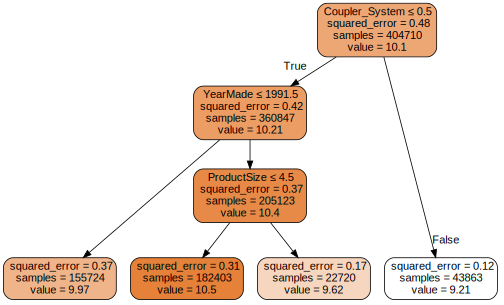

In [43]:
draw_tree(m, xs, size=7, leaves_parallel = True, precision = 2)

In [44]:
samp_idx = np.random.permutation(len(y))[:500]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


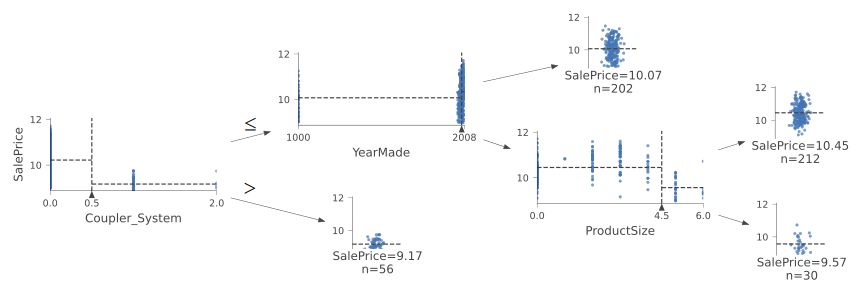

In [45]:
dtreeviz(m, xs.iloc[samp_idx], y.iloc[samp_idx], xs.columns, dep_var, fontname='DejaVu Sans', scale = 1.6, label_fontsize=10,
         orientation='LR')

In [46]:
xs.loc[xs['YearMade']<1900,'YearMade'] = 1950
valid_xs.loc[valid_xs['YearMade']<1900,'YearMade'] = 1950

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


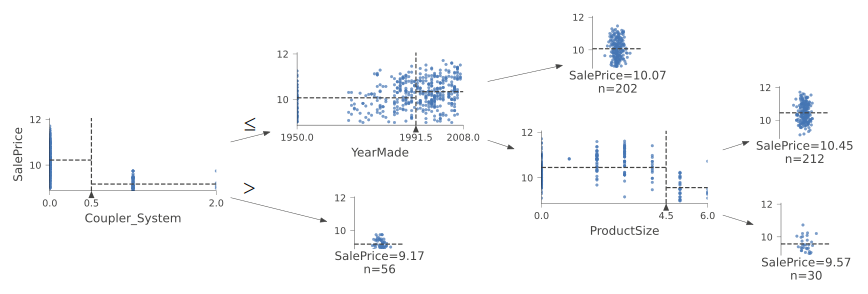

In [47]:
m = DecisionTreeRegressor(max_leaf_nodes=4)
m.fit(xs, y)
dtreeviz(m, xs.iloc[samp_idx], y.iloc[samp_idx], xs.columns, dep_var, fontname='DejaVu Sans', scale = 1.6, label_fontsize=10,
         orientation='LR')

In [48]:
m = DecisionTreeRegressor()
m.fit(xs, y)

DecisionTreeRegressor()

In [49]:
def r_mse(pred, y): return round(math.sqrt(((pred-y)**2).mean()), 6)
def m_rmse(m, xs, y): return r_mse(m.predict(xs), y)

In [50]:
m_rmse(m, xs, y)

0.0

In [51]:
m_rmse(m, valid_xs, valid_y)

0.334935

In [52]:
m.get_n_leaves(), len(xs)

(np.int64(324560), 404710)

In [53]:
m = DecisionTreeRegressor(min_samples_leaf=25)
m.fit(xs, y)
m_rmse(m, xs, y), m_rmse(m, valid_xs, valid_y)

(0.211706, 0.268875)

In [54]:
m.get_n_leaves()

np.int64(12400)

In [55]:
def rf(xs, y, n_estimators = 40, max_samples = 200000, max_features = 0.5, min_samples_leaf = 5, **kwargs):
  return RandomForestRegressor(n_jobs=-1, n_estimators=n_estimators, max_samples=max_samples, max_features=max_features,
                               min_samples_leaf=min_samples_leaf, oob_score=True).fit(xs, y)

In [56]:
m = rf(xs, y)

In [57]:
m_rmse(m, xs, y), m_rmse(m, valid_xs, valid_y)

(0.170966, 0.232699)

In [58]:
preds = np.stack([t.predict(valid_xs) for t in m.estimators_])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

In [60]:
r_mse(preds.mean(0), valid_y)

0.232699

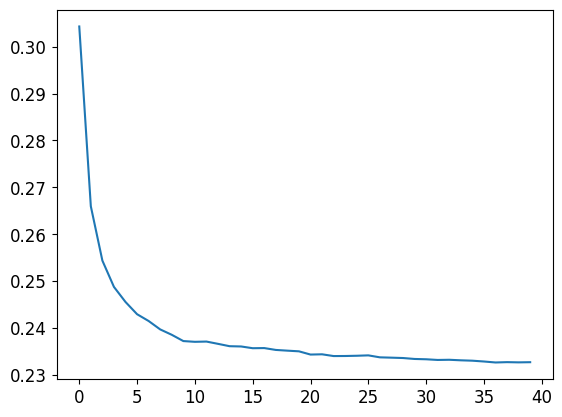

In [61]:
plt.plot([r_mse(preds[:i+1].mean(0), valid_y) for i in range(40)]);

In [62]:
r_mse(m.oob_prediction_, y)

0.210776

In [63]:
preds = np.stack([t.predict(valid_xs) for t in m.estimators_])
preds.shape

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

(40, 7988)

In [64]:
preds_std = preds.std(0)

In [65]:
preds_std[:5]

array([0.26069358, 0.10409366, 0.09904178, 0.27184634, 0.13110276])

In [66]:
def rf_feat_importance(m, df):
    return pd.DataFrame({'cols':df.columns, 'imp':m.feature_importances_}
                       ).sort_values('imp', ascending=False)

In [67]:
fi = rf_feat_importance(m, xs)
fi[:10]

,cols,imp
57,YearMade,0.173023
6,ProductSize,0.117253
30,Coupler_System,0.117053
7,fiProductClassDesc,0.073112
54,ModelID,0.054777
65,saleElapsed,0.048835
3,fiSecondaryDesc,0.046104
31,Grouser_Tracks,0.041196
12,Enclosure,0.040495
32,Hydraulics_Flow,0.032725


In [68]:
def plt_fi(fi):
  return fi.plot('cols', 'imp', 'barh', figsize=(12,7), legend=False)

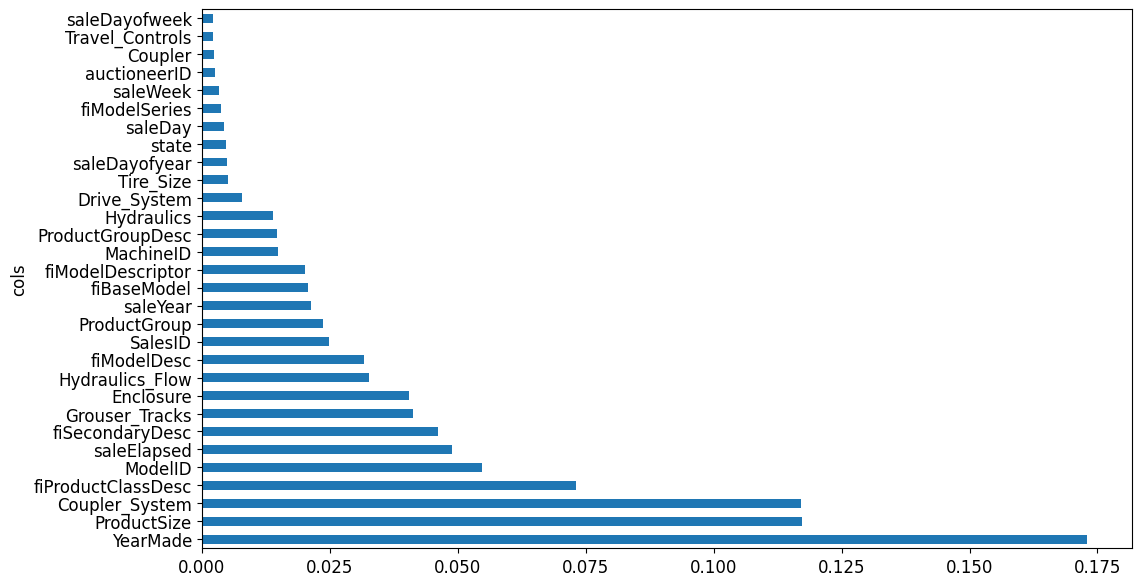

In [69]:
plt_fi(fi[:30]);

In [70]:
to_keep = fi[fi.imp > 0.005].cols
len(to_keep)

21

In [71]:
xs_imp = xs[to_keep]
valid_xs_imp = valid_xs[to_keep]

In [72]:
m = rf(xs_imp, y)

In [73]:
m_rmse(m, xs_imp, y), m_rmse(m, valid_xs_imp, valid_y)

(0.18131, 0.230503)

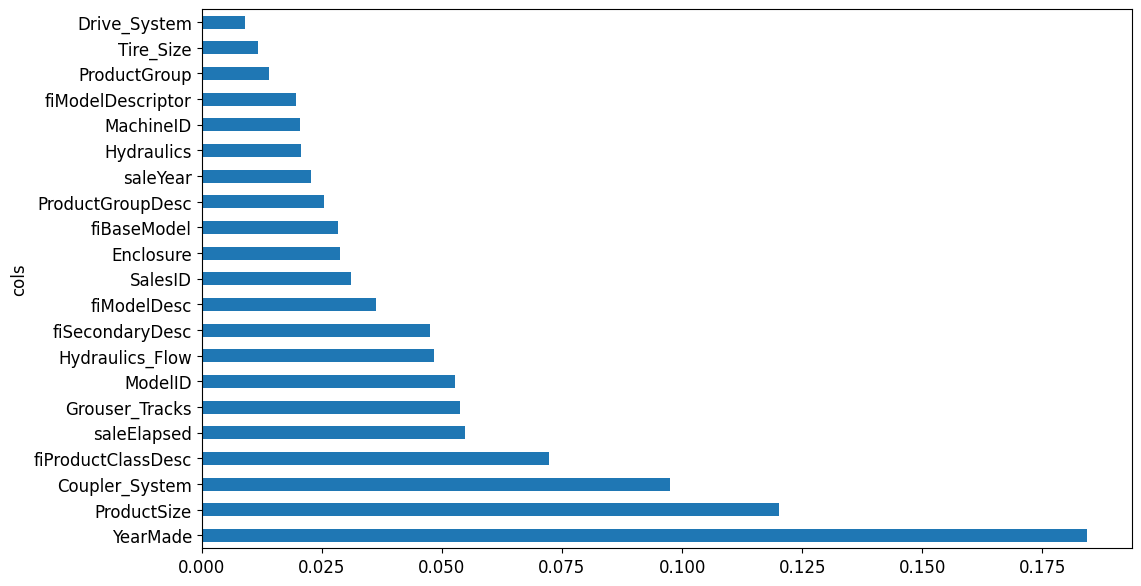

In [76]:
plt_fi(rf_feat_importance(m, xs_imp));

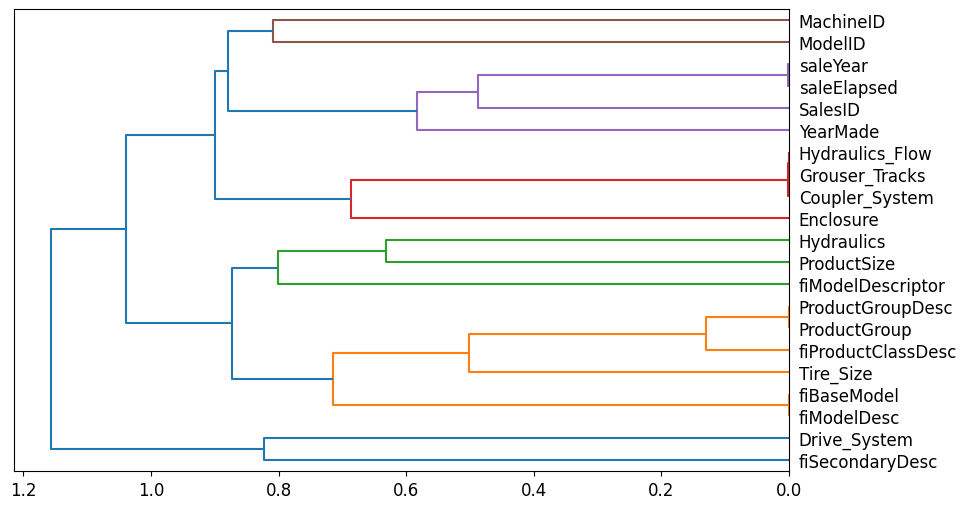

In [77]:
cluster_columns(xs_imp)

In [78]:
def get_oob(df):
  m = RandomForestRegressor(n_estimators=40, min_samples_leaf=15, max_samples=50000, max_features=0.5, n_jobs=-1, oob_score=True)
  m.fit(df, y)
  return m.oob_score_

In [79]:
get_oob(xs_imp)

0.8781576734893485

In [80]:
{c: get_oob(xs_imp.drop(c, axis =1)) for c in ('saleYear', 'saleElapsed', 'ProductGroupDesc','ProductGroup','fiModelDesc',
                                               'fiBaseModel','Hydraulics_Flow','Grouser_Tracks','Coupler_System')}

{'saleYear': 0.8768628311464004,
 'saleElapsed': 0.8722097904682757,
 'ProductGroupDesc': 0.8770087512874477,
 'ProductGroup': 0.8778594920344923,
 'fiModelDesc': 0.8754781084425128,
 'fiBaseModel': 0.8761168180455399,
 'Hydraulics_Flow': 0.8774995916903535,
 'Grouser_Tracks': 0.8775565092698138,
 'Coupler_System': 0.8770165273393064}

In [81]:
to_drop = ['saleYear','ProductGroupDesc','fiBaseModel','Grouser_Tracks']
get_oob(xs_imp.drop(to_drop, axis = 1))

0.8750482697068109

In [82]:
xs_final = xs_imp.drop(to_drop, axis = 1)
valid_xs_final = valid_xs_imp.drop(to_drop, axis = 1)

In [83]:
m = rf(xs_final, y)
m_rmse(m, xs_final, y), m_rmse(m, valid_xs_final, valid_y)

(0.183251, 0.232259)

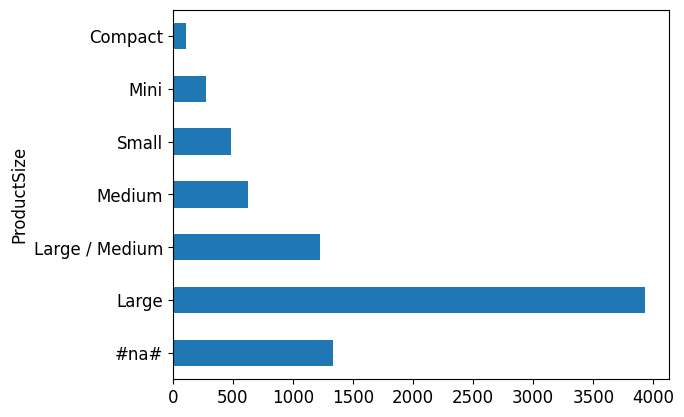

In [84]:
p = valid_xs_final['ProductSize'].value_counts(sort = False).plot.barh()
c = to.classes['ProductSize']
plt.yticks(range(len(c)), c);

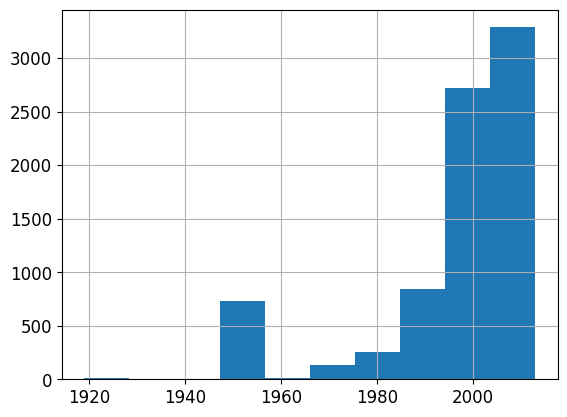

In [85]:
ax = valid_xs_final['YearMade'].hist()

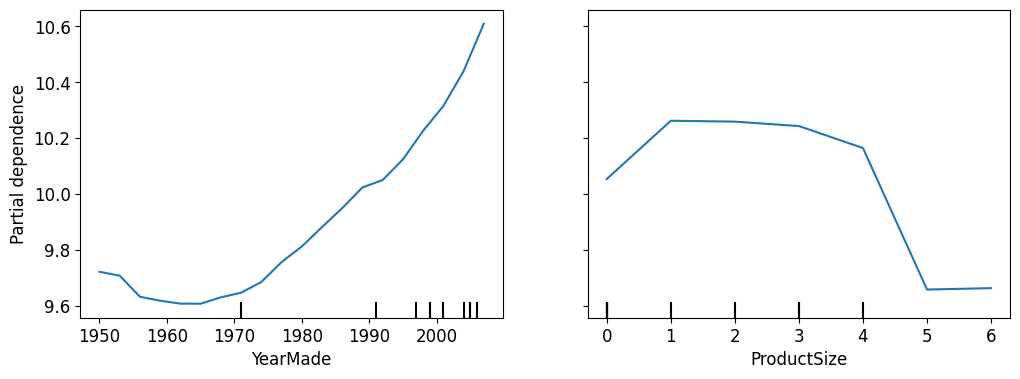

In [87]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(m, valid_xs_final, ['YearMade','ProductSize'], grid_resolution = 20, ax = ax);

In [89]:
row = valid_xs_final.iloc[:5]

In [94]:
from treeinterpreter import treeinterpreter as ti
prediction, bias, contributions = ti.predict(m, row.values)

In [96]:
prediction[0], bias[0], contributions[0].sum()

(array([9.94708073]),
 np.float64(10.104746057831763),
 np.float64(-0.15766532528651994))

In [99]:
!pip install waterfallcharts

In [102]:
waterfall_chart.plot()

<module 'waterfall_chart' from '/usr/local/lib/python3.12/dist-packages/waterfall_chart.py'>

/usr/local/lib/python3.12/dist-packages/waterfall_chart.py:141: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = y_height[loop] + row['amount']
/usr/local/lib/python3.12/dist-packages/waterfall_chart.py:139: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = y_height[loop]


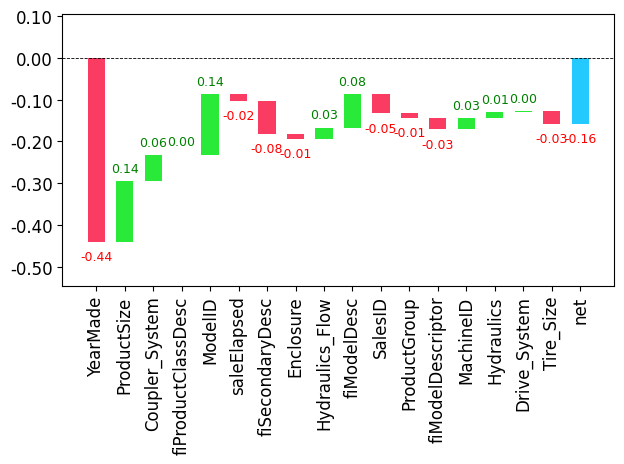

In [106]:
waterfall_chart.plot(valid_xs_final.columns, contributions[0], threshold = 0.00, rotation_value = 90,
                          formatting = '{:,.2f}');

In [107]:
df_dom = pd.concat([xs_final, valid_xs_final])

In [108]:
is_valid = np.array([0]*len(xs_final)+[1]*len(valid_xs_final))

In [109]:
m = rf(df_dom, is_valid)

In [110]:
rf_feat_importance(m, df_dom)[:6]

,cols,imp
5,saleElapsed,0.896565
10,SalesID,0.076535
13,MachineID,0.021677
0,YearMade,0.001536
4,ModelID,0.000771
9,fiModelDesc,0.000484


In [111]:
m = rf(xs_final, y)
print('orig ', m_rmse(m, valid_xs_final, valid_y))

orig  0.232182


In [112]:
for c in ('SalesID','saleElapsed','MachineID'):
  m = rf(xs_final.drop(c, axis = 1), y)
  print(c, m_rmse(m, valid_xs_final.drop(c, axis = 1), valid_y))

SalesID 0.231425
saleElapsed 0.234604
MachineID 0.230814


In [113]:
time_vars = ['SalesID','MachineID']
xs_final_time = xs_final.drop(time_vars, axis = 1)
valid_xs_final_time = valid_xs_final.drop(time_vars, axis = 1)

In [114]:
m = rf(xs_final_time, y)
m_rmse(m, valid_xs_final_time, valid_y)

0.23003

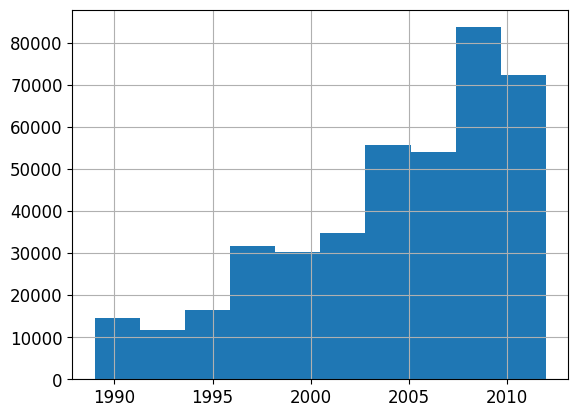

In [115]:
xs['saleYear'].hist();

In [116]:
filt = xs['saleYear'] > 2004
xs_filt = xs_final_time[filt]
y_filt = y[filt]

In [117]:
m = rf(xs_filt, y_filt)
m_rmse(m, xs_filt, y_filt), m_rmse(m, valid_xs_final_time, valid_y)

(0.177613, 0.228965)

In [130]:
df_nn = pd.read_csv("/content/data/TrainAndValid.csv", low_memory=False)
df_nn['ProductSize'] = df_nn['ProductSize'].astype('category')
df_nn['ProductSize'] = df_nn['ProductSize'].cat.set_categories(sizes, ordered=True)
df_nn[dep_var] = np.log(df_nn['SalePrice'])
df_nn = add_datepart(df_nn, 'saledate')

In [131]:
df_nn_final = df_nn[list(xs_final_time.columns)+[dep_var]]

In [132]:
cont_nn, cat_nn = cont_cat_split(df_nn_final, max_card = 9000, dep_var=dep_var)

In [133]:
df_nn_final[cat_nn].nunique()

,0
YearMade,73
ProductSize,6
Coupler_System,2
fiProductClassDesc,74
ModelID,5281
fiSecondaryDesc,177
Enclosure,6
Hydraulics_Flow,3
fiModelDesc,5059
ProductGroup,6


In [123]:
xs_filt2 = xs_filt.drop('fiModelDescriptor', axis = 1)
valid_xs_time2 = valid_xs_final_time.drop('fiModelDescriptor', axis = 1)

In [124]:
m2 = rf(xs_filt2, y_filt)
m_rmse(m2, xs_filt2, y_filt), m_rmse(m2, valid_xs_time2, valid_y)

(0.176811, 0.230324)

In [134]:
cat_nn.remove('fiModelDescriptor')

In [135]:
procs_nn = [Categorify, FillMissing, Normalize]
to_nn = TabularPandas(df_nn_final, procs=procs_nn, cat_names=cat_nn, cont_names=cont_nn, y_names=dep_var, splits=splits)

In [136]:
dls = to_nn.dataloaders(bs=1024)

In [137]:
y = to_nn.train.y

In [138]:
y.min(), y.max()

(8.465899467468262, 11.863582611083984)

In [139]:
from fastai.tabular.all import *

In [140]:
learn = tabular_learner(dls, y_range=(8,12),layers = [500,250], n_out = 1, loss_func = F.mse_loss)

<div></div>

SuggestedLRs(valley=0.0003311311302240938)

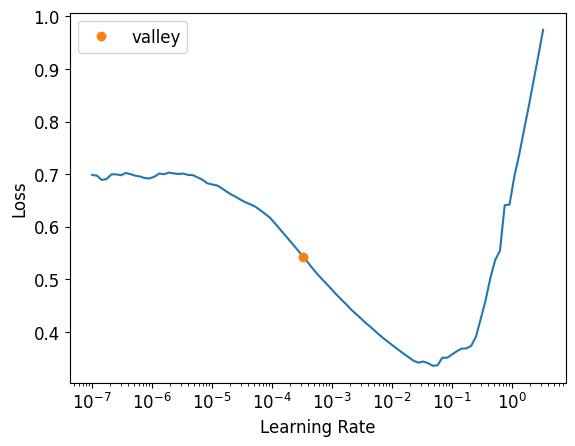

In [141]:
learn.lr_find()

In [142]:
learn.fit_one_cycle(5, 1e-2)

epoch,train_loss,valid_loss,time
0,0.061509,0.076083,00:38
1,0.052451,0.057385,00:34
2,0.046693,0.058664,00:37
3,0.041865,0.052643,00:32
4,0.039827,0.051776,00:32


In [143]:
preds, targs = learn.get_preds()

In [144]:
r_mse(preds, targs)

0.227543

In [145]:
rf_preds = m.predict(valid_xs_final_time)

In [146]:
ens_preds = (to_np(preds.squeeze())+rf_preds)/2

In [147]:
r_mse(ens_preds, valid_y)

0.222685